# Synthetic Testbed Validation: RAMA vs Baselines

This notebook demonstrates a **three-phase synthetic testbed validation** of Rank-Aware Moment Aggregation (RAMA):

- **Phase A**: Rank collapse measurement and variance-entropy proxy validation (Spearman correlation)
- **Phase B**: Comparison of aggregation methods (Mean, UngatedMeanVar, RAMA, PNA, VPA) on regression & classification
- **Phase C**: RAMA gate behavior analysis — gate values correlate with child-set cardinality

The experiment uses a synthetic relational dataset with controlled rank-collapse conditions (varying cardinality and projection rank).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# Colab versions: numpy==2.0.2, scipy==1.16.3, scikit-learn==1.6.1, matplotlib==3.10.0, seaborn==0.13.2
# Use compatible ranges for broader Python version support
if 'google.colab' not in sys.modules:
    _pip('torch', '--index-url', 'https://download.pytorch.org/whl/cpu')
    _pip('numpy==2.0.2')
    _pip('scipy>=1.14', 'scikit-learn>=1.5', 'matplotlib>=3.9', 'seaborn>=0.13')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time
import warnings
from collections import defaultdict
from typing import Optional

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from loguru import logger
from scipy import stats as scipy_stats
from sklearn.metrics import accuracy_score, r2_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset

# Setup logger for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

print(f"PyTorch {torch.__version__}, NumPy {np.__version__}")

PyTorch 2.10.0+cpu, NumPy 2.0.2


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter2_synthetic_testb/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
raw_data = load_data()
print(f"Loaded {len(raw_data['datasets'][0]['examples'])} examples")
print(f"Dataset: {raw_data['datasets'][0]['dataset']}")

Loaded 81 examples
Dataset: synthetic_relational_rank_collapse_testbed


## Configuration

All tunable parameters for the experiment. Reduced from original values for a quick demo run.

In [5]:
# === Data dimensions (must match the dataset) ===
CHILD_DIM = 16
PARENT_DIM = 8

# === Model architecture ===
HIDDEN_DIM = 64       # Original: 64

# === Training parameters ===
NUM_SEEDS = 3         # Original: 5
NUM_EPOCHS = 50       # Original: 100
LR = 0.001
PATIENCE = 12         # Original: 15
BATCH_SIZE = 32       # Original: 64
EPS = 1e-8

# === Methods to compare ===
METHOD_NAMES = ["mean", "ungated_meanvar", "rama", "pna", "vpa"]  # All 5 original methods
TASK_NAMES = ["regression", "classification"]

# === Condition structure ===
REGIMES = ["low", "medium", "high", "extreme"]
RANKS = [2, 8, 16]

torch.set_num_threads(max(1, os.cpu_count() or 1))
print(f"Config: {NUM_SEEDS} seeds, {NUM_EPOCHS} epochs, {len(METHOD_NAMES)} methods, batch_size={BATCH_SIZE}")

Config: 3 seeds, 50 epochs, 5 methods, batch_size=32


## Parse Dataset

Parse the loaded JSON examples into NumPy arrays for training. Each example has parent features, variable-length child features, regression and classification targets, plus metadata about rank collapse conditions.

In [6]:
def parse_data(raw, max_examples=None):
    """Parse raw JSON into structured numpy arrays."""
    metadata = raw.get("metadata", {})
    examples_raw = raw["datasets"][0]["examples"]
    if max_examples is not None:
        examples_raw = examples_raw[:max_examples]

    print(f"Parsing {len(examples_raw)} examples...")
    examples = []
    for i, ex in enumerate(examples_raw):
        try:
            inp = json.loads(ex["input"])
            out = json.loads(ex["output"])
            examples.append({
                "idx": i,
                "parent_features": np.array(inp["parent_features"], dtype=np.float32),
                "child_features": np.array(inp["child_features"], dtype=np.float32),
                "num_children": int(inp["num_children"]),
                "regression_target": float(out["regression_target"]),
                "classification_target": int(out["classification_target"]),
                "fold": ex.get("metadata_fold", "train"),
                "condition": ex.get("metadata_condition", "unknown"),
                "cardinality_regime": ex.get("metadata_cardinality_regime", ""),
                "cardinality": int(ex.get("metadata_cardinality", 1)),
                "projection_rank": int(ex.get("metadata_projection_rank", 1)),
                "erank_svd": float(ex.get("metadata_erank_svd", 1.0)),
                "erank_proxy": float(ex.get("metadata_erank_proxy", 0.5)),
                "child_mean": np.array(ex.get("metadata_child_mean", [0.0]*CHILD_DIM), dtype=np.float32),
                "child_variance": np.array(ex.get("metadata_child_variance", [0.0]*CHILD_DIM), dtype=np.float32),
            })
        except Exception as e:
            print(f"Failed to parse example {i}: {e}")
            continue

    by_fold = defaultdict(list)
    by_condition = defaultdict(list)
    for ex in examples:
        by_fold[ex["fold"]].append(ex)
        by_condition[ex["condition"]].append(ex)

    print(f"Parsed {len(examples)} examples")
    print(f"Folds: {', '.join(f'{k}={len(v)}' for k, v in sorted(by_fold.items()))}")
    print(f"Conditions: {sorted(by_condition.keys())}")

    return {"metadata": metadata, "examples": examples, "by_fold": dict(by_fold), "by_condition": dict(by_condition)}

data = parse_data(raw_data)
CONDITIONS = sorted(data["by_condition"].keys())
print(f"\nActive conditions: {CONDITIONS}")

Parsing 81 examples...
Parsed 81 examples
Folds: test=18, train=45, val=18
Conditions: ['low_rank16', 'low_rank2', 'low_rank8', 'medium_rank16', 'medium_rank2', 'medium_rank8']

Active conditions: ['low_rank16', 'low_rank2', 'low_rank8', 'medium_rank16', 'medium_rank2', 'medium_rank8']


## Scatter Operations

Pure PyTorch scatter operations for aggregation (no external torch_scatter dependency).

In [7]:
def scatter_mean(src, index, dim_size):
    """Mean aggregation: (E, d), (E,) -> (dim_size, d)."""
    out = torch.zeros(dim_size, src.size(1), device=src.device, dtype=src.dtype)
    count = torch.zeros(dim_size, 1, device=src.device, dtype=src.dtype)
    idx_exp = index.unsqueeze(1).expand_as(src)
    out.scatter_add_(0, idx_exp, src)
    ones = torch.ones(src.size(0), 1, device=src.device, dtype=src.dtype)
    count.scatter_add_(0, index.unsqueeze(1), ones)
    return out / count.clamp(min=1)

def scatter_sum(src, index, dim_size):
    """Sum aggregation: (E, d), (E,) -> (dim_size, d)."""
    out = torch.zeros(dim_size, src.size(1), device=src.device, dtype=src.dtype)
    idx_exp = index.unsqueeze(1).expand_as(src)
    out.scatter_add_(0, idx_exp, src)
    return out

def scatter_max(src, index, dim_size):
    """Max aggregation: (E, d), (E,) -> (dim_size, d)."""
    try:
        out = src.new_full((dim_size, src.size(1)), float('-inf'))
        idx_exp = index.unsqueeze(1).expand_as(src)
        out.scatter_reduce_(0, idx_exp, src, reduce="amax")
        return out
    except Exception:
        parts = []
        for j in range(dim_size):
            mask = (index == j)
            if mask.any():
                parts.append(src[mask].max(dim=0).values)
            else:
                parts.append(src.new_full((src.size(1),), float('-inf')))
        return torch.stack(parts, dim=0)

def scatter_count(index, dim_size):
    """Count elements per group: (E,) -> (dim_size, 1)."""
    ones = torch.ones(index.size(0), 1, device=index.device)
    count = torch.zeros(dim_size, 1, device=index.device)
    count.scatter_add_(0, index.unsqueeze(1), ones)
    return count

print("Scatter operations defined.")

Scatter operations defined.


## Model Definitions

Five aggregation models compared in this experiment:
1. **MeanAgg**: Simple mean of child embeddings (baseline)
2. **UngatedMeanVar**: Concatenates mean and variance, projects down
3. **RAMA**: Rank-Aware Moment Aggregation — gates variance contribution based on effective rank proxy
4. **PNA**: PNA-style with mean + std + max and degree scaling
5. **VPA**: Variance-Preserving Aggregation (sum / sqrt(N))

In [8]:
class ChildEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(CHILD_DIM, HIDDEN_DIM)
    def forward(self, x):
        return F.relu(self.fc(x))

class ParentEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(PARENT_DIM, HIDDEN_DIM)
    def forward(self, x):
        return F.relu(self.fc(x))

class PredictionHead(nn.Module):
    def __init__(self, input_dim=2 * HIDDEN_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, HIDDEN_DIM)
        self.fc2 = nn.Linear(HIDDEN_DIM, 1)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

class MeanAggModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.child_enc = ChildEncoder()
        self.parent_enc = ParentEncoder()
        self.head = PredictionHead(2 * HIDDEN_DIM)
    def forward(self, x_children, parent_idx, x_parents, dim_size):
        h = self.child_enc(x_children)
        agg = scatter_mean(h, parent_idx, dim_size)
        hp = self.parent_enc(x_parents)
        return self.head(torch.cat([agg, hp], dim=1))

class UngatedMeanVarModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.child_enc = ChildEncoder()
        self.parent_enc = ParentEncoder()
        self.proj = nn.Linear(2 * HIDDEN_DIM, HIDDEN_DIM)
        self.head = PredictionHead(2 * HIDDEN_DIM)
    def forward(self, x_children, parent_idx, x_parents, dim_size):
        h = self.child_enc(x_children)
        mu = scatter_mean(h, parent_idx, dim_size)
        mean_x2 = scatter_mean(h * h, parent_idx, dim_size)
        var = (mean_x2 - mu * mu).clamp(min=0)
        agg = F.relu(self.proj(torch.cat([mu, var], dim=1)))
        hp = self.parent_enc(x_parents)
        return self.head(torch.cat([agg, hp], dim=1))

class RAMAModel(nn.Module):
    """RAMA: Rank-Aware Moment Aggregation (our method)."""
    def __init__(self, gate_hidden=16):
        super().__init__()
        self.child_enc = ChildEncoder()
        self.parent_enc = ParentEncoder()
        self.W_sigma = nn.Linear(HIDDEN_DIM, HIDDEN_DIM, bias=False)
        self.W_g = nn.Linear(2, gate_hidden)
        self.gate_out = nn.Linear(gate_hidden, HIDDEN_DIM)
        self.head = PredictionHead(2 * HIDDEN_DIM)
        nn.init.zeros_(self.W_sigma.weight)
        nn.init.zeros_(self.gate_out.weight)
        nn.init.zeros_(self.gate_out.bias)
        nn.init.xavier_uniform_(self.W_g.weight)
        nn.init.zeros_(self.W_g.bias)

    def _rama_aggregate(self, h_child, parent_idx, dim_size):
        mu = scatter_mean(h_child, parent_idx, dim_size)
        mean_x2 = scatter_mean(h_child * h_child, parent_idx, dim_size)
        var = (mean_x2 - mu * mu).clamp(min=0)
        N = scatter_count(parent_idx, dim_size)
        var_sum = var.sum(dim=-1, keepdim=True).clamp(min=EPS)
        p = (var / var_sum).clamp(min=EPS)
        H = -(p * p.log()).sum(dim=-1, keepdim=True)
        log_d = math.log(HIDDEN_DIM)
        rho = H / log_d
        gate_input = torch.cat([torch.log1p(N), rho], dim=-1)
        g = torch.sigmoid(self.gate_out(F.relu(self.W_g(gate_input))))
        agg = mu + g * self.W_sigma(var)
        return agg, g, rho, N

    def forward(self, x_children, parent_idx, x_parents, dim_size):
        h = self.child_enc(x_children)
        agg, _, _, _ = self._rama_aggregate(h, parent_idx, dim_size)
        hp = self.parent_enc(x_parents)
        return self.head(torch.cat([agg, hp], dim=1))

    def get_gate_values(self, x_children, parent_idx, x_parents, dim_size):
        h = self.child_enc(x_children)
        _, g, rho, N = self._rama_aggregate(h, parent_idx, dim_size)
        return g, rho, N

class PNAModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.child_enc = ChildEncoder()
        self.parent_enc = ParentEncoder()
        self.proj = nn.Linear(3 * HIDDEN_DIM, HIDDEN_DIM)
        self.head = PredictionHead(2 * HIDDEN_DIM)
        self.register_buffer('avg_deg_log', torch.tensor(1.0))
    def set_avg_degree(self, train_degrees):
        self.avg_deg_log = torch.tensor(float(np.log(np.mean(train_degrees) + 1)))
    def forward(self, x_children, parent_idx, x_parents, dim_size):
        h = self.child_enc(x_children)
        mu = scatter_mean(h, parent_idx, dim_size)
        mean_x2 = scatter_mean(h * h, parent_idx, dim_size)
        var = (mean_x2 - mu * mu).clamp(min=0)
        std = torch.sqrt(var + 1e-8)
        mx = scatter_max(h, parent_idx, dim_size)
        N = scatter_count(parent_idx, dim_size)
        scaler = torch.log(N + 1) / self.avg_deg_log.clamp(min=1e-8)
        agg = F.relu(self.proj(torch.cat([mu, std, mx], dim=1))) * scaler
        hp = self.parent_enc(x_parents)
        return self.head(torch.cat([agg, hp], dim=1))

class VPAModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.child_enc = ChildEncoder()
        self.parent_enc = ParentEncoder()
        self.head = PredictionHead(2 * HIDDEN_DIM)
    def forward(self, x_children, parent_idx, x_parents, dim_size):
        h = self.child_enc(x_children)
        s = scatter_sum(h, parent_idx, dim_size)
        N = scatter_count(parent_idx, dim_size)
        agg = s / torch.sqrt(N.clamp(min=1))
        hp = self.parent_enc(x_parents)
        return self.head(torch.cat([agg, hp], dim=1))

MODEL_CLASSES = {
    "mean": MeanAggModel, "ungated_meanvar": UngatedMeanVarModel,
    "rama": RAMAModel, "pna": PNAModel, "vpa": VPAModel,
}
print(f"Defined {len(MODEL_CLASSES)} model classes: {list(MODEL_CLASSES.keys())}")

Defined 5 model classes: ['mean', 'ungated_meanvar', 'rama', 'pna', 'vpa']


## Dataset, DataLoader & Training

Custom PyTorch Dataset that handles variable-length child sets via a custom collate function. Training uses early stopping on validation loss.

In [9]:
class RelationalDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {
            "parent_features": torch.from_numpy(ex["parent_features"]),
            "child_features": torch.from_numpy(ex["child_features"]),
            "regression_target": torch.tensor(ex["regression_target"], dtype=torch.float32),
            "classification_target": torch.tensor(float(ex["classification_target"]), dtype=torch.float32),
            "idx": ex["idx"],
        }

def collate_fn(batch):
    parents = torch.stack([b["parent_features"] for b in batch])
    y_reg = torch.stack([b["regression_target"] for b in batch])
    y_cls = torch.stack([b["classification_target"] for b in batch])
    indices = [b["idx"] for b in batch]
    children_list, pidx_list = [], []
    for i, b in enumerate(batch):
        c = b["child_features"]
        children_list.append(c)
        pidx_list.append(torch.full((c.size(0),), i, dtype=torch.long))
    return {
        "x_children": torch.cat(children_list, dim=0),
        "parent_idx": torch.cat(pidx_list, dim=0),
        "x_parents": parents, "y_reg": y_reg, "y_cls": y_cls, "indices": indices,
    }

def make_loader(examples, shuffle=False):
    bs = min(BATCH_SIZE, len(examples))
    return DataLoader(RelationalDataset(examples), batch_size=bs, shuffle=shuffle,
                      collate_fn=collate_fn, num_workers=0, drop_last=False)

def train_one_model(method_name, task, train_examples, val_examples, seed, train_degrees):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = MODEL_CLASSES[method_name]()
    if method_name == "pna":
        model.set_avg_degree(train_degrees)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss() if task == "regression" else nn.BCEWithLogitsLoss()
    train_loader = make_loader(train_examples, shuffle=True)
    val_loader = make_loader(val_examples, shuffle=False)
    best_val_loss, best_state, patience_ctr = float('inf'), None, 0

    for epoch in range(NUM_EPOCHS):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            pred = model(batch["x_children"], batch["parent_idx"],
                         batch["x_parents"], batch["x_parents"].size(0)).squeeze(-1)
            target = batch["y_reg"] if task == "regression" else batch["y_cls"]
            loss = criterion(pred, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss_sum, val_n = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                pred = model(batch["x_children"], batch["parent_idx"],
                             batch["x_parents"], batch["x_parents"].size(0)).squeeze(-1)
                target = batch["y_reg"] if task == "regression" else batch["y_cls"]
                val_loss_sum += criterion(pred, target).item() * pred.size(0)
                val_n += pred.size(0)
        val_loss = val_loss_sum / max(val_n, 1)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                break
    return best_state, best_val_loss, epoch + 1

def predict_all(model, examples, task):
    model.eval()
    loader = make_loader(examples, shuffle=False)
    predictions = {}
    with torch.no_grad():
        for batch in loader:
            pred = model(batch["x_children"], batch["parent_idx"],
                         batch["x_parents"], batch["x_parents"].size(0)).squeeze(-1)
            for i, idx in enumerate(batch["indices"]):
                predictions[idx] = pred[i].item() if task == "regression" else torch.sigmoid(pred[i]).item()
    return predictions

def evaluate_predictions(predictions, examples, task):
    y_true, y_pred = [], []
    for ex in examples:
        if ex["idx"] in predictions:
            y_true.append(ex["regression_target"] if task == "regression" else ex["classification_target"])
            y_pred.append(predictions[ex["idx"]])
    if not y_true:
        return {"mse": float('nan'), "r2": float('nan')} if task == "regression" else {"accuracy": float('nan'), "auroc": float('nan')}
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    if task == "regression":
        mse = float(np.mean((y_true - y_pred) ** 2))
        r2 = float(r2_score(y_true, y_pred)) if len(y_true) > 1 else 0.0
        return {"mse": mse, "r2": r2}
    else:
        acc = float(accuracy_score(y_true, (y_pred >= 0.5).astype(int)))
        try:
            auroc = float(roc_auc_score(y_true, y_pred))
        except ValueError:
            auroc = 0.5
        return {"accuracy": acc, "auroc": auroc}

print("Training infrastructure ready.")

Training infrastructure ready.


## Phase A: Rank Collapse Analysis

Measure rank collapse across conditions and validate the variance-entropy proxy against the SVD-based effective rank. The proxy should strongly correlate with SVD effective rank (high Spearman ρ).

In [10]:
def _compute_erank_of_matrix(M):
    if M.shape[0] < 2:
        return 1.0
    Mc = M - M.mean(axis=0)
    cov = Mc.T @ Mc / M.shape[0]
    sigmas = np.linalg.svd(cov, compute_uv=False)
    sigmas = sigmas[sigmas > EPS]
    if len(sigmas) == 0:
        return 1.0
    p = sigmas / sigmas.sum()
    H = -np.sum(p * np.log(p + EPS))
    return float(np.exp(H))

def _compute_erank_from_child_matrix(C):
    if C.shape[0] < 2:
        return 1.0
    Cc = C - C.mean(axis=0)
    cov = Cc.T @ Cc / C.shape[0]
    sigmas = np.linalg.svd(cov, compute_uv=False)
    sigmas = sigmas[sigmas > EPS]
    if len(sigmas) == 0:
        return 1.0
    p = sigmas / sigmas.sum()
    H = -np.sum(p * np.log(p + EPS))
    return float(np.exp(H))

def phase_a_rank_analysis(data):
    print("=" * 50)
    print("PHASE A: Rank Collapse Analysis")
    print("=" * 50)
    examples = data["examples"]
    by_condition = data["by_condition"]

    # A1: Overall proxy vs SVD correlation
    all_svd = np.array([ex["erank_svd"] for ex in examples])
    all_proxy = np.array([ex["erank_proxy"] for ex in examples])

    if len(all_svd) > 2:
        sp_all = scipy_stats.spearmanr(all_svd, all_proxy)
        pe_all = scipy_stats.pearsonr(all_svd, all_proxy)
        sp_rho, sp_p = float(sp_all.statistic), float(sp_all.pvalue)
        pe_r, pe_p = float(pe_all.statistic), float(pe_all.pvalue)
    else:
        sp_rho, sp_p, pe_r, pe_p = 0.0, 1.0, 0.0, 1.0
    print(f"Proxy vs SVD overall: Spearman={sp_rho:.4f} Pearson={pe_r:.4f}")

    # A1b: Per-cardinality correlations
    per_card_corr = {}
    for regime in REGIMES:
        regime_exs = [ex for ex in examples if ex["cardinality_regime"] == regime]
        if len(regime_exs) > 2:
            svds = np.array([ex["erank_svd"] for ex in regime_exs])
            prxs = np.array([ex["erank_proxy"] for ex in regime_exs])
            sp = scipy_stats.spearmanr(svds, prxs)
            per_card_corr[regime] = {"spearman": float(sp.statistic), "pvalue": float(sp.pvalue)}
            print(f"  {regime}: Spearman={sp.statistic:.4f} (n={len(regime_exs)})")

    # A2: Per-condition rank statistics
    per_cond_stats = []
    for cond in CONDITIONS:
        cexs = by_condition.get(cond, [])
        if not cexs:
            continue
        eranks_svd = np.array([e["erank_svd"] for e in cexs])
        eranks_proxy = np.array([e["erank_proxy"] for e in cexs])
        card = cexs[0]["cardinality"]
        proj_rank = cexs[0]["projection_rank"]
        max_rank = min(card, CHILD_DIM)
        collapse_ratios = eranks_svd / max_rank
        mean_vecs = np.stack([e["child_mean"] for e in cexs])
        erank_of_means = _compute_erank_of_matrix(mean_vecs)
        stat = {
            "condition": cond, "cardinality": card, "projection_rank": proj_rank,
            "num_examples": len(cexs), "max_possible_rank": max_rank,
            "mean_erank_svd": float(np.mean(eranks_svd)),
            "std_erank_svd": float(np.std(eranks_svd)),
            "mean_erank_proxy": float(np.mean(eranks_proxy)),
            "mean_collapse_ratio": float(np.mean(collapse_ratios)),
        }
        per_cond_stats.append(stat)
        print(f"  {cond}: erank={stat['mean_erank_svd']:.2f} collapse={stat['mean_collapse_ratio']:.3f}")

    return {
        "proxy_vs_svd_correlation": {"spearman": sp_rho, "pearson": pe_r},
        "per_cardinality_correlation": per_card_corr,
        "per_condition_rank_stats": per_cond_stats,
    }

phase_a_results = phase_a_rank_analysis(data)

PHASE A: Rank Collapse Analysis
Proxy vs SVD overall: Spearman=0.8545 Pearson=0.7952
  low: Spearman=0.6503 (n=54)
  medium: Spearman=0.9428 (n=27)
  low_rank16: erank=3.42 collapse=0.685
  low_rank2: erank=2.33 collapse=0.466
  low_rank8: erank=3.10 collapse=0.620
  medium_rank16: erank=13.49 collapse=0.843
  medium_rank2: erank=3.64 collapse=0.228
  medium_rank8: erank=7.76 collapse=0.485


## Phase B: Model Comparison

Train and evaluate aggregation methods on both regression and classification tasks. Compare across conditions with different cardinality regimes and projection ranks.

In [11]:
def phase_b_model_comparison(data):
    print("=" * 50)
    print("PHASE B: Model Comparison")
    print("=" * 50)

    by_fold = data["by_fold"]
    examples = data["examples"]
    train_ex = by_fold.get("train", [])
    val_ex = by_fold.get("val", [])
    test_ex = by_fold.get("test", [])
    print(f"Train: {len(train_ex)}, Val: {len(val_ex)}, Test: {len(test_ex)}")

    if not train_ex or not val_ex:
        print("Insufficient data for training")
        return {"results_summary": {}, "all_predictions": {}}, {}

    train_degrees = [ex["cardinality"] for ex in train_ex]
    all_results = {}
    all_predictions = {}
    rama_reg_states = {}

    total_runs = len(METHOD_NAMES) * len(TASK_NAMES) * NUM_SEEDS
    run_count = 0
    t_start = time.time()

    for method in METHOD_NAMES:
        for task in TASK_NAMES:
            for seed in range(NUM_SEEDS):
                run_count += 1
                t_run = time.time()
                print(f"[{run_count}/{total_runs}] {method}/{task}/seed{seed}", end=" ")

                try:
                    best_state, best_val, epochs = train_one_model(
                        method, task, train_ex, val_ex, seed, train_degrees)
                    model = MODEL_CLASSES[method]()
                    if method == "pna":
                        model.set_avg_degree(train_degrees)
                    model.load_state_dict(best_state)

                    if method == "rama" and task == "regression":
                        rama_reg_states[seed] = {k: v.clone() for k, v in best_state.items()}

                    preds_all = predict_all(model, examples, task)
                    all_predictions[(method, task, seed)] = preds_all
                    overall = evaluate_predictions(preds_all, test_ex, task)
                    per_cond = {}
                    for cond in CONDITIONS:
                        cond_test = [e for e in test_ex if e["condition"] == cond]
                        if cond_test:
                            per_cond[cond] = evaluate_predictions(preds_all, cond_test, task)

                    all_results[(method, task, seed)] = {"overall": overall, "per_condition": per_cond, "epochs": epochs}
                    dt = time.time() - t_run
                    m_str = (f"MSE={overall.get('mse',0):.2f} R2={overall.get('r2',0):.3f}" if task == "regression"
                             else f"Acc={overall.get('accuracy',0):.3f} AUC={overall.get('auroc',0):.3f}")
                    print(f"-> {dt:.1f}s, {epochs}ep, {m_str}")
                    del model, best_state
                    gc.collect()
                except Exception as e:
                    print(f"FAILED: {e}")
                    all_results[(method, task, seed)] = None

    total_time = time.time() - t_start
    print(f"\nPhase B done in {total_time:.0f}s ({total_time/60:.1f} min)")

    # Aggregate results
    summary = {}
    for task in TASK_NAMES:
        task_sum = {"overall": [], "per_condition": []}
        for method in METHOD_NAMES:
            seeds = [all_results.get((method, task, s)) for s in range(NUM_SEEDS)]
            seeds = [s for s in seeds if s is not None]
            if seeds:
                if task == "regression":
                    mses = [s["overall"]["mse"] for s in seeds]
                    r2s = [s["overall"]["r2"] for s in seeds]
                    task_sum["overall"].append({"method": method, "mean_mse": float(np.mean(mses)),
                                                 "std_mse": float(np.std(mses)), "mean_r2": float(np.mean(r2s))})
                else:
                    accs = [s["overall"]["accuracy"] for s in seeds]
                    aucs = [s["overall"]["auroc"] for s in seeds]
                    task_sum["overall"].append({"method": method, "mean_accuracy": float(np.mean(accs)),
                                                 "mean_auroc": float(np.mean(aucs))})
                for cond in CONDITIONS:
                    sc = [s for s in seeds if s and cond in s["per_condition"]]
                    if sc:
                        if task == "regression":
                            task_sum["per_condition"].append({"condition": cond, "method": method,
                                "mean_mse": float(np.mean([s["per_condition"][cond]["mse"] for s in sc])),
                                "mean_r2": float(np.mean([s["per_condition"][cond]["r2"] for s in sc]))})
                        else:
                            task_sum["per_condition"].append({"condition": cond, "method": method,
                                "mean_accuracy": float(np.mean([s["per_condition"][cond]["accuracy"] for s in sc])),
                                "mean_auroc": float(np.mean([s["per_condition"][cond]["auroc"] for s in sc]))})
        summary[task] = task_sum

    return {"results_summary": summary, "all_predictions": all_predictions, "training_time": total_time}, rama_reg_states

phase_b_results, rama_states = phase_b_model_comparison(data)

PHASE B: Model Comparison
Train: 45, Val: 18, Test: 18
[1/30] mean/regression/seed0 

-> 8.4s, 50ep, MSE=724.98 R2=-0.012
[2/30] mean/regression/seed1 

-> 1.5s, 50ep, MSE=789.36 R2=-0.102
[3/30] mean/regression/seed2 

-> 1.5s, 50ep, MSE=657.32 R2=0.083
[4/30] mean/classification/seed0 

-> 1.3s, 39ep, Acc=0.722 AUC=0.738
[5/30] mean/classification/seed1 

...

-> 1.5s, 50ep, MSE=1733.67 R2=-1.419
[27/30] vpa/regression/seed2 

-> 1.5s, 50ep, MSE=1616.80 R2=-1.256
[28/30] vpa/classification/seed0 

-> 1.1s, 36ep, Acc=0.667 AUC=0.638
[29/30] vpa/classification/seed1 

-> 1.2s, 40ep, Acc=0.556 AUC=0.650
[30/30] vpa/classification/seed2 

-> 1.2s, 37ep, Acc=0.611 AUC=0.688

Phase B done in 71s (1.2 min)


## Phase C: RAMA Gate Analysis

Analyze the learned gate values of the RAMA model. Gates should correlate with child-set cardinality (higher cardinality → higher gate activation, allowing more variance information through).

In [12]:
def phase_c_gate_analysis(data, rama_reg_states):
    print("=" * 50)
    print("PHASE C: Gate Analysis")
    print("=" * 50)

    test_ex = data["by_fold"].get("test", [])
    if not test_ex or not rama_reg_states:
        print("No test data or RAMA states for gate analysis")
        return {}

    test_lookup = {ex["idx"]: ex for ex in test_ex}
    all_gate_data = []

    for seed, state in rama_reg_states.items():
        print(f"Extracting gates from RAMA seed {seed}...")
        model = RAMAModel()
        model.load_state_dict(state)
        model.eval()
        loader = make_loader(test_ex, shuffle=False)
        with torch.no_grad():
            for batch in loader:
                g, rho, N = model.get_gate_values(
                    batch["x_children"], batch["parent_idx"],
                    batch["x_parents"], batch["x_parents"].size(0))
                for i, idx in enumerate(batch["indices"]):
                    ex = test_lookup[idx]
                    all_gate_data.append({
                        "seed": seed, "idx": idx, "condition": ex["condition"],
                        "cardinality": ex["cardinality"], "projection_rank": ex["projection_rank"],
                        "erank_svd": ex["erank_svd"], "erank_proxy": ex["erank_proxy"],
                        "gate_mean": float(g[i].mean().item()),
                        "rho": float(rho[i].item()), "N": float(N[i].item()),
                    })
        del model
        gc.collect()

    if not all_gate_data:
        return {}

    # Per-condition gate stats
    gate_by_cond = defaultdict(lambda: {"gates": [], "rhos": []})
    for gd in all_gate_data:
        gate_by_cond[gd["condition"]]["gates"].append(gd["gate_mean"])
        gate_by_cond[gd["condition"]]["rhos"].append(gd["rho"])

    per_cond_gate = []
    gate_heatmap = {}
    for cond in CONDITIONS:
        if cond in gate_by_cond:
            gs = np.array(gate_by_cond[cond]["gates"])
            stat = {"condition": cond, "mean_gate": float(np.mean(gs)), "std_gate": float(np.std(gs))}
            per_cond_gate.append(stat)
            gate_heatmap[cond] = stat["mean_gate"]
            print(f"  {cond}: gate={stat['mean_gate']:.4f}+/-{stat['std_gate']:.4f}")

    # Correlations
    gm = [gd["gate_mean"] for gd in all_gate_data]
    lc = [np.log(gd["cardinality"] + 1) for gd in all_gate_data]
    if len(gm) > 2 and len(set(lc)) > 1:
        gc_sp = scipy_stats.spearmanr(gm, lc)
        gate_card_corr = {"spearman": float(gc_sp.statistic)}
        print(f"Gate vs log(cardinality): Spearman={gc_sp.statistic:.4f}")
    else:
        gate_card_corr = {"spearman": 0.0}

    return {"gate_heatmap": gate_heatmap, "gate_vs_cardinality": gate_card_corr,
            "per_condition_gate_stats": per_cond_gate, "all_gate_data": all_gate_data}

phase_c_results = phase_c_gate_analysis(data, rama_states)

PHASE C: Gate Analysis
Extracting gates from RAMA seed 0...


Extracting gates from RAMA seed 1...


Extracting gates from RAMA seed 2...


  low_rank16: gate=0.6626+/-0.0112
  low_rank2: gate=0.6613+/-0.0112
  low_rank8: gate=0.6612+/-0.0112
  medium_rank16: gate=0.7624+/-0.0203
  medium_rank2: gate=0.7614+/-0.0212
  medium_rank8: gate=0.7626+/-0.0201
Gate vs log(cardinality): Spearman=0.8166


## Results Visualization

Summary of key findings across all three phases: rank collapse patterns, method comparison, and gate behavior.

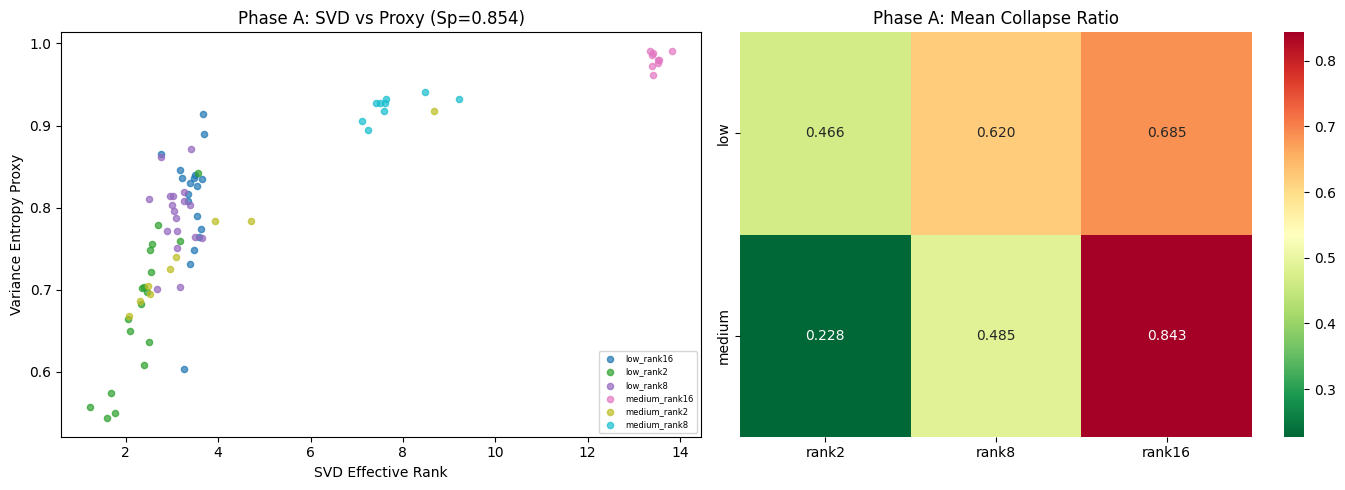

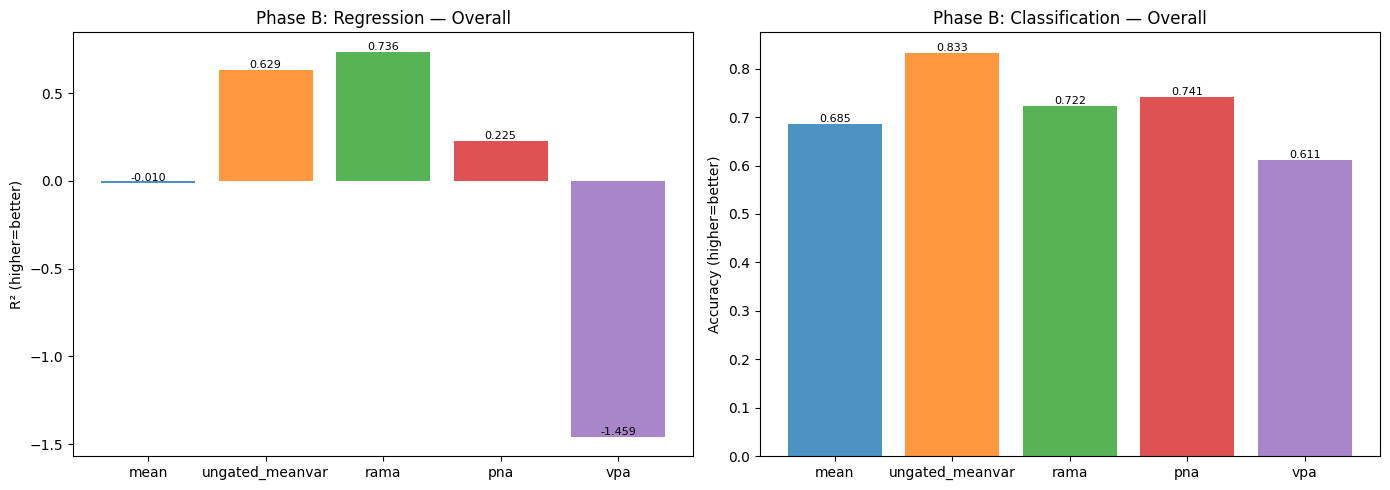

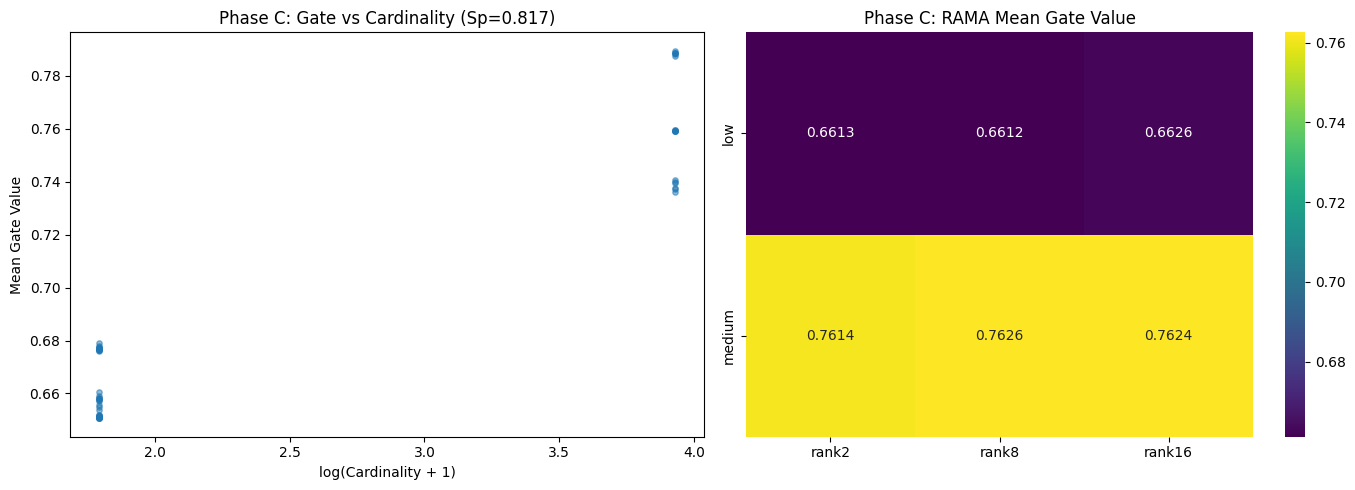


RESULTS SUMMARY

Phase A — Proxy vs SVD Spearman: 0.8545

Phase B — Overall Results:
  regression/mean: R²=-0.0101
  regression/ungated_meanvar: R²=0.6293
  regression/rama: R²=0.7362
  regression/pna: R²=0.2250
  regression/vpa: R²=-1.4591
  classification/mean: Acc=0.6852, AUC=0.8042
  classification/ungated_meanvar: Acc=0.8333, AUC=0.9625
  classification/rama: Acc=0.7222, AUC=0.9083
  classification/pna: Acc=0.7407, AUC=0.8875
  classification/vpa: Acc=0.6111, AUC=0.6583

Phase C — Gate vs Cardinality Spearman: 0.8166

Training time: 71.2s


In [13]:
# ===== Phase A Visualization: Proxy vs SVD =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Proxy vs SVD scatter
ax = axes[0]
examples = data["examples"]
conds = sorted(set(ex["condition"] for ex in examples))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(conds), 1)))
cond2c = dict(zip(conds, colors))
for c in conds:
    exs = [e for e in examples if e["condition"] == c]
    ax.scatter([e["erank_svd"] for e in exs], [e["erank_proxy"] for e in exs],
               c=[cond2c[c]], label=c, alpha=0.7, s=20)
ax.set_xlabel("SVD Effective Rank")
ax.set_ylabel("Variance Entropy Proxy")
corr = phase_a_results["proxy_vs_svd_correlation"]
ax.set_title(f"Phase A: SVD vs Proxy (Sp={corr['spearman']:.3f})")
ax.legend(fontsize=6, loc='lower right')

# Plot 2: Rank collapse heatmap
ax = axes[1]
per_cond = phase_a_results.get("per_condition_rank_stats", [])
avail_regimes = sorted(set(s["condition"].split("_rank")[0] for s in per_cond if "_rank" in s["condition"]))
avail_ranks = sorted(set(int(s["condition"].split("_rank")[1]) for s in per_cond if "_rank" in s["condition"]))
if avail_regimes and avail_ranks:
    hdata = np.full((len(avail_regimes), len(avail_ranks)), np.nan)
    for stat in per_cond:
        parts = stat["condition"].split("_rank")
        if len(parts) == 2 and parts[0] in avail_regimes and int(parts[1]) in avail_ranks:
            hdata[avail_regimes.index(parts[0]), avail_ranks.index(int(parts[1]))] = stat["mean_collapse_ratio"]
    sns.heatmap(hdata, annot=True, fmt=".3f", xticklabels=[f"rank{r}" for r in avail_ranks],
                yticklabels=avail_regimes, cmap="RdYlGn_r", ax=ax)
    ax.set_title("Phase A: Mean Collapse Ratio")
plt.tight_layout()
plt.show()

# ===== Phase B Visualization: Method Comparison =====
summary = phase_b_results.get("results_summary", {})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, task in enumerate(TASK_NAMES):
    ax = axes[idx]
    task_data = summary.get(task, {})
    overall = task_data.get("overall", [])
    if overall:
        methods = [x["method"] for x in overall]
        if task == "regression":
            vals = [x["mean_r2"] for x in overall]
            ylabel = "R² (higher=better)"
        else:
            vals = [x["mean_accuracy"] for x in overall]
            ylabel = "Accuracy (higher=better)"
        colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(methods)]
        bars = ax.bar(methods, vals, color=colors_bar, alpha=0.8)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Phase B: {task.capitalize()} — Overall")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{v:.3f}',
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# ===== Phase C Visualization: Gate Analysis =====
if phase_c_results and phase_c_results.get("all_gate_data"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    all_gate_data = phase_c_results["all_gate_data"]
    gm = [gd["gate_mean"] for gd in all_gate_data]
    lc = [np.log(gd["cardinality"] + 1) for gd in all_gate_data]

    # Gate vs cardinality
    ax = axes[0]
    ax.scatter(lc, gm, alpha=0.5, s=15)
    ax.set_xlabel("log(Cardinality + 1)")
    ax.set_ylabel("Mean Gate Value")
    sp_str = f"Sp={phase_c_results['gate_vs_cardinality'].get('spearman', 0):.3f}"
    ax.set_title(f"Phase C: Gate vs Cardinality ({sp_str})")

    # Gate heatmap
    ax = axes[1]
    gate_stats = phase_c_results.get("per_condition_gate_stats", [])
    if gate_stats:
        avail_regimes_g = sorted(set(s["condition"].split("_rank")[0] for s in gate_stats if "_rank" in s["condition"]))
        avail_ranks_g = sorted(set(int(s["condition"].split("_rank")[1]) for s in gate_stats if "_rank" in s["condition"]))
        if avail_regimes_g and avail_ranks_g:
            gdata = np.full((len(avail_regimes_g), len(avail_ranks_g)), np.nan)
            for stat in gate_stats:
                parts = stat["condition"].split("_rank")
                if len(parts) == 2 and parts[0] in avail_regimes_g and int(parts[1]) in avail_ranks_g:
                    gdata[avail_regimes_g.index(parts[0]), avail_ranks_g.index(int(parts[1]))] = stat["mean_gate"]
            sns.heatmap(gdata, annot=True, fmt=".4f", xticklabels=[f"rank{r}" for r in avail_ranks_g],
                        yticklabels=avail_regimes_g, cmap="viridis", ax=ax)
            ax.set_title("Phase C: RAMA Mean Gate Value")
    plt.tight_layout()
    plt.show()
else:
    print("No gate analysis data to visualize.")

# ===== Summary Table =====
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"\nPhase A — Proxy vs SVD Spearman: {phase_a_results['proxy_vs_svd_correlation']['spearman']:.4f}")
print(f"\nPhase B — Overall Results:")
for task in TASK_NAMES:
    task_data = summary.get(task, {})
    for r in task_data.get("overall", []):
        if task == "regression":
            print(f"  {task}/{r['method']}: R²={r['mean_r2']:.4f}")
        else:
            print(f"  {task}/{r['method']}: Acc={r['mean_accuracy']:.4f}, AUC={r['mean_auroc']:.4f}")
if phase_c_results and phase_c_results.get("gate_vs_cardinality"):
    print(f"\nPhase C — Gate vs Cardinality Spearman: {phase_c_results['gate_vs_cardinality'].get('spearman', 0):.4f}")
print(f"\nTraining time: {phase_b_results.get('training_time', 0):.1f}s")